# Caso Práctico 1: Motor de recomendación de películas

En este caso práctico vamos a construir tres sistemas de recomendación utilizando las valoraciones de MovieLens.

Primero veremos qué películas son las más populares. Después haremos filtrado colaborativo de dos formas: buscando usuarios con gustos parecidos y buscando películas que suelen recibir valoraciones similares. La idea es comparar los tres métodos y entender en qué situación tiene más sentido utilizar cada uno.


## 1. Imports, carga y exploración de los datos

Vamos a usar `pandas` para preparar los datos y calcular las recomendaciones, y `matplotlib` para representar los resultados.

Al ejecutar la siguiente celda tenemos que seleccionar a la vez `file.tsv` y `Movie_Id_Titles.csv`.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Subimos directamente los dos ficheros
files.upload()

valoraciones = pd.read_csv(
    'file.tsv',
    sep='\t',
    names=['usuario_id', 'pelicula_id', 'rating', 'timestamp']
)
peliculas = pd.read_csv('Movie_Id_Titles.csv')

# Unimos valoraciones y títulos. La fecha no aporta nada a estos filtros.
datos = (valoraciones.drop(columns='timestamp')
         .merge(peliculas, left_on='pelicula_id', right_on='item_id', how='left')
         .drop(columns='item_id'))

print(f'Valoraciones: {len(datos):,}')
print(f'Usuarios: {datos.usuario_id.nunique():,}')
print(f'Películas: {datos.pelicula_id.nunique():,}')
print(f'Valores nulos: {datos.isna().sum().sum()}')
datos.head()


Saving file.tsv to file.tsv
Saving Movie_Id_Titles.csv to Movie_Id_Titles.csv
Valoraciones: 100,003
Usuarios: 944
Películas: 1,682
Valores nulos: 0


,usuario_id,pelicula_id,rating,title
0,0,50,5,Star Wars (1977)
1,0,172,5,"Empire Strikes Back, The (1980)"
2,0,133,1,Gone with the Wind (1939)
3,196,242,3,Kolya (1996)
4,186,302,3,L.A. Confidential (1997)


El dataset contiene el identificador del usuario, la película y una puntuación de 1 a 5. No tenemos información sobre género, edad o tipo de película, así que las recomendaciones dependerán únicamente de las valoraciones.

Una celda vacío no es una mala nota, simplemente no sabemos si ese usuario ha visto la película.


## 2. Recomendación basada en popularidad

Empezamos por el método más sencillo. Consideraremos más popular la película que haya recibido más valoraciones.

También mostraremos la nota media para tener algo de contexto, pero no la utilizaremos para ordenar. Una película con muchos votos no tiene por qué ser la mejor valorada; simplemente es la que más usuarios han puntuado.


In [21]:
import plotly.express as px
import numpy as np

# Calculamos popularidad y nota media
popularidad = (datos.groupby(['pelicula_id', 'title']).rating
               .agg(num_valoraciones='count', nota_media='mean')
               .sort_values('num_valoraciones', ascending=False))

# Mostramos el Top 10 en formato tabla
top_10_titulos = popularidad.head(10).index.get_level_values('title').tolist()
display(popularidad.head(10))

# Preparamos los datos para la gráfica (Top 200)
grafica_df = popularidad.head(200).reset_index()

# Creamos una columna para diferenciar el estilo de los puntos
grafica_df['es_top_10'] = grafica_df['title'].apply(lambda x: 'Top 10 Popular' if x in top_10_titulos else 'Resto')

fig = px.scatter(
    grafica_df,
    x='num_valoraciones',
    y='nota_media',
    hover_name='title',
    color='nota_media',
    symbol='es_top_10', # Diferenciamos por símbolo
    symbol_map={'Top 10 Popular': 'star', 'Resto': 'circle'},
    size=grafica_df['es_top_10'].replace({'Top 10 Popular': 3, 'Resto': 2}), # Estrellas más grandes
    title='Relación Popularidad vs Calidad (Destacando el Top 10)',
    labels={'num_valoraciones': 'Número de valoraciones', 'nota_media': 'Nota media'},
    color_continuous_scale='RdYlGn'
)

# Mejoramos la estética
fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(height=600, template='plotly_white', showlegend=False)
fig.show()

,,num_valoraciones,nota_media
pelicula_id,title,,
50,Star Wars (1977),584,4.359589
258,Contact (1997),509,3.803536
100,Fargo (1996),508,4.155512
181,Return of the Jedi (1983),507,4.007890
294,Liar Liar (1997),485,3.156701
286,"English Patient, The (1996)",481,3.656965
288,Scream (1996),478,3.441423
1,Toy Story (1995),452,3.878319
300,Air Force One (1997),431,3.631090


/tmp/ipykernel_2168/2030535811.py:27: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Este método funciona bien para un usuario nuevo porque no necesita saber nada sobre él. El problema es que devuelve prácticamente la misma lista para todo el mundo y favorece siempre a las películas más conocidas.


## 3. Matriz usuario-película

Para los dos filtros colaborativos necesitamos convertir los datos en una matriz. Cada fila representa a un usuario, cada columna una película y cada celda contiene la valoración.

Vamos a mantener los valores vacíos como `NaN`. Rellenarlos con cero sería asumir que el usuario ha visto la película y le ha puesto la peor nota, y eso cambiaría completamente el significado de los datos.


In [5]:
matriz_usuario_pelicula = datos.pivot_table(
    index='usuario_id',
    columns='title',
    values='rating'
)

porcentaje_vacio = matriz_usuario_pelicula.isna().mean().mean()
print('Dimensiones:', matriz_usuario_pelicula.shape)
print(f'Porcentaje sin valorar: {porcentaje_vacio:.2%}')
matriz_usuario_pelicula.iloc[:5, :8]


Dimensiones: (944, 1664)
Porcentaje sin valorar: 93.65%


title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968)
usuario_id,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Filtrado colaborativo basado en usuarios

En este caso buscamos usuarios que hayan puntuado de forma parecida. Usaremos correlación de Pearson, que es la que indica el enunciado y `pandas` permite calcularla directamente.

La correlación se calcula solo sobre películas que ambos usuarios hayan valorado. Además, exigimos un mínimo de 20 coincidencias para no decidir que dos personas se parecen porque han puntuado igual una o dos películas. Nos quedaremos con los 20 vecinos más cercanos y combinaremos sus notas mediante una media ponderada.


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Vecinos utilizados: 20


,title,prediccion,vecinos_que_la_valoran
26,Die Hard (1988),5.0,3
93,Pulp Fiction (1994),5.0,3
1,Alien (1979),5.0,2
10,Blade Runner (1982),5.0,2
29,"Empire Strikes Back, The (1980)",5.0,2
36,Face/Off (1997),5.0,2
50,Good Will Hunting (1997),5.0,2
51,GoodFellas (1990),5.0,2
104,Schindler's List (1993),5.0,2
110,"Silence of the Lambs, The (1991)",5.0,2


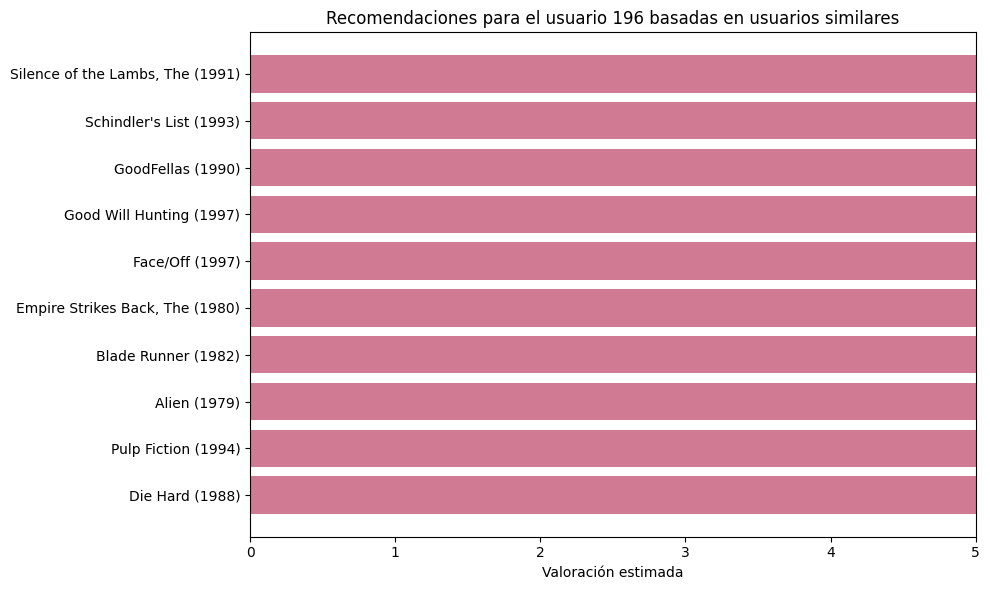

In [7]:
def recomendar_por_usuarios(usuario_id, top_n=10, minimo_comun=20):
    objetivo = matriz_usuario_pelicula.loc[usuario_id]

    # Buscamos correlaciones positivas y eliminamos al propio usuario.
    similitudes = (matriz_usuario_pelicula
                   .corrwith(objetivo, axis=1)
                   .drop(index=usuario_id, errors='ignore')
                   .dropna())
    vecinos = similitudes[similitudes > 0].sort_values(ascending=False).head(20)

    predicciones = []
    for titulo in objetivo[objetivo.isna()].index:
        notas = matriz_usuario_pelicula.loc[vecinos.index, titulo].dropna()
        pesos = vecinos.loc[notas.index]
        if len(notas) >= 2 and pesos.sum() > 0:
            predicciones.append({
                'title': titulo,
                'prediccion': (notas * pesos).sum() / pesos.sum(),
                'vecinos_que_la_valoran': len(notas)
            })

    return (pd.DataFrame(predicciones)
            .sort_values(['prediccion', 'vecinos_que_la_valoran'], ascending=False)
            .head(top_n)), vecinos

USUARIO_EJEMPLO = 196
recomendaciones_usuario, vecinos = recomendar_por_usuarios(USUARIO_EJEMPLO)

print(f'Vecinos utilizados: {len(vecinos)}')
display(recomendaciones_usuario)

mostrar = recomendaciones_usuario.sort_values('prediccion')
plt.figure(figsize=(10, 6))
plt.barh(mostrar.title, mostrar.prediccion, color='#D07A93')
plt.title(f'Recomendaciones para el usuario {USUARIO_EJEMPLO} basadas en usuarios similares')
plt.xlabel('Valoración estimada')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()


Ahora sí obtenemos una lista personalizada. Dos usuarios pueden recibir resultados diferentes porque sus vecinos también serán diferentes.

La principal limitación es que necesitamos suficientes películas en común para calcular una correlación fiable. Si el usuario acaba de llegar o tiene gustos muy poco habituales, puede que no encontremos vecinos útiles.


## 5. Filtrado colaborativo basado en ítems

El tercer método compara películas en lugar de personas. La lógica es sencilla: si dos películas suelen recibir notas parecidas de los mismos usuarios, consideramos que están relacionadas.

Volvemos a usar Pearson y exigimos al menos 50 valoraciones comunes. Para construir la lista personalizada partimos de las películas que el usuario ha puntuado con 4 o 5 y buscamos títulos similares. Personalmente, este método me parece más fácil de explicar porque podemos decir directamente qué película del historial ha provocado cada recomendación.


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-pa

,title,score_item_item,porque
463,Swept from the Sea (1997),5.0,"English Patient, The (1996)"
453,Hurricane Streets (1998),5.0,Secrets & Lies (1996)
455,Loaded (1994),5.0,Secrets & Lies (1996)
739,Primary Colors (1998),5.0,Stand by Me (1986)
28,I Know What You Did Last Summer (1997),5.0,Ace Ventura: Pet Detective (1994)
27,Paradise Lost: The Child Murders at Robin Hood...,5.0,Ace Ventura: Pet Detective (1994)
735,"Corrina, Corrina (1994)",5.0,Stand by Me (1986)
736,Body Snatchers (1993),5.0,Stand by Me (1986)
741,"Day the Earth Stood Still, The (1951)",5.0,Stand by Me (1986)
740,"Bronx Tale, A (1993)",5.0,Stand by Me (1986)


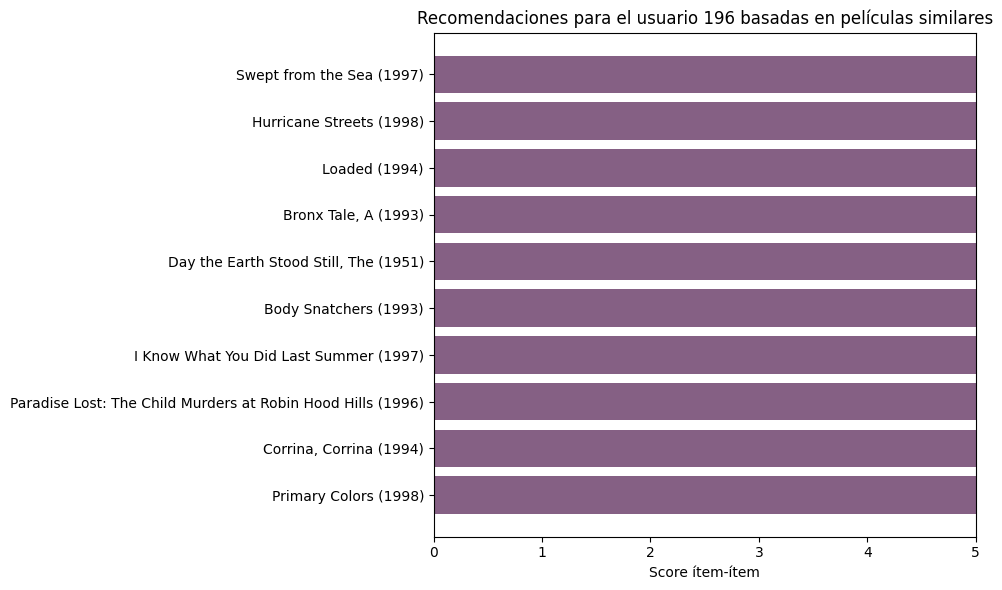

In [8]:
matriz_pelicula_usuario = matriz_usuario_pelicula.T

def peliculas_similares(titulo, top_n=100, minimo_comun=50):
    objetivo = matriz_pelicula_usuario.loc[titulo]
    similitudes = (matriz_pelicula_usuario
                   .corrwith(objetivo, axis=1)
                   .drop(index=titulo, errors='ignore')
                   .dropna())
    return similitudes[similitudes > 0].sort_values(ascending=False).head(top_n)

def recomendar_por_items(usuario_id, top_n=10):
    historial = matriz_usuario_pelicula.loc[usuario_id].dropna()
    favoritas = historial[historial >= 4]
    candidatos = {}

    # Cada película favorita aporta candidatos según su similitud.
    for titulo, rating in favoritas.items():
        for candidata, similitud in peliculas_similares(titulo).items():
            if candidata in historial.index:
                continue
            fila = candidatos.setdefault(
                candidata,
                {'suma': 0, 'peso': 0, 'porque': titulo, 'mejor_aporte': 0}
            )
            aporte = similitud * rating
            fila['suma'] += aporte
            fila['peso'] += similitud
            if aporte > fila['mejor_aporte']:
                fila['porque'] = titulo
                fila['mejor_aporte'] = aporte

    recomendaciones = [
        {
            'title': titulo,
            'score_item_item': fila['suma'] / fila['peso'],
            'porque': fila['porque']
        }
        for titulo, fila in candidatos.items()
        if fila['peso'] > 0
    ]
    return (pd.DataFrame(recomendaciones)
            .sort_values('score_item_item', ascending=False)
            .head(top_n))

recomendaciones_items = recomendar_por_items(USUARIO_EJEMPLO)
display(recomendaciones_items)

mostrar = recomendaciones_items.sort_values('score_item_item')
plt.figure(figsize=(10, 6))
plt.barh(mostrar.title, mostrar.score_item_item, color='#856084')
plt.title(f'Recomendaciones para el usuario {USUARIO_EJEMPLO} basadas en películas similares')
plt.xlabel('Score ítem-ítem')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()


La columna `porque` hace que el resultado sea bastante transparente: podemos ver qué película ya valorada ha tenido más influencia en cada sugerencia.

Este enfoque suele ser más estable que comparar usuarios, pero sigue dependiendo de que existan suficientes valoraciones comunes entre las películas. Los títulos menos conocidos van a tener más dificultades para aparecer.


## 6. Comparación de los resultados

No existe un método que sea siempre mejor. Cada uno resuelve una parte distinta del problema, así que vamos a resumir qué hemos obtenido y dónde falla cada enfoque.


In [9]:
comparacion = pd.DataFrame({
    'Método': ['Popularidad', 'Usuarios similares', 'Ítems similares'],
    '¿Personaliza?': ['No', 'Sí', 'Sí'],
    'Necesita historial': ['No', 'Sí, y coincidencias con otros usuarios', 'Sí, y películas con suficientes votos'],
    'Punto fuerte': [
        'Funciona desde la primera visita',
        'Aprovecha gustos de personas parecidas',
        'Es estable y permite explicar el motivo'
    ],
    'Limitación principal': [
        'Recomienda lo mismo a todo el mundo',
        'Sufre cuando hay pocas valoraciones comunes',
        'Favorece películas con bastante historial'
    ]
})

comparacion


,Método,¿Personaliza?,Necesita historial,Punto fuerte,Limitación principal
0,Popularidad,No,No,Funciona desde la primera visita,Recomienda lo mismo a todo el mundo
1,Usuarios similares,Sí,"Sí, y coincidencias con otros usuarios",Aprovecha gustos de personas parecidas,Sufre cuando hay pocas valoraciones comunes
2,Ítems similares,Sí,"Sí, y películas con suficientes votos",Es estable y permite explicar el motivo,Favorece películas con bastante historial


## 7. Conclusiones

En este caso práctico hemos implementado los tres métodos que pedía el enunciado utilizando `pandas`. El ranking de popularidad es el más sencillo y funciona bien para arrancar, aunque no tiene ninguna personalización. El filtrado por usuarios sí adapta el resultado, pero necesita suficientes coincidencias para encontrar vecinos fiables.

El filtrado basado en ítems es el que más me convence para este dataset. Además de personalizar, permite justificar cada resultado a partir de una película que el usuario ya ha valorado bien. Aun así, también tiene sesgo hacia los títulos con más información y no resuelve por sí solo el problema de un usuario completamente nuevo.

Como ampliación he desarrollado CineMatch, una web que representa visualmente estos tres enfoques. La aplicación añade una mezcla híbrida con pesos dinámicos: al principio se apoya más en popularidad y, cuando el perfil acumula valoraciones, da más peso a usuarios e ítems similares. También incorpora perfiles locales y metadatos de TMDB. Estas mejoras no sustituyen los tres filtros del ejercicio; simplemente los combinan y los presentan de una forma más cercana a una aplicación real.
